# Prototype: Run a Sobol sensitivity analysis with the model

In [1]:

import os
import importlib
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import numpy as np
import pandas as pd

from SALib.sample import sobol as sample_sobol
from SALib.analyze import sobol as analyse_sobol

import inframind_proteus.outbreak_dynamics
from inframind_proteus.outbreak_dynamics.sampling import sample_lhs

importlib.reload(inframind_proteus.outbreak_dynamics)
from inframind_proteus.outbreak_dynamics import (
    SimulationConfig, RenewalSimulator, SimulationOutput,
    LogisticRT, ConstantGammaGT, build_calibration_params_df,
    build_initial_infec_df
)


from inframind_proteus.outbreak_dynamics.utils import (
    load_yaml_dict, epiweek_to_date
)


In [4]:

# ===========

# --- Load configuration dict
config_dict = load_yaml_dict(Path("../../configs/outbreak_dynamics_example.yaml"))
simulator = RenewalSimulator.from_config_dict(config_dict)
config = simulator.config

# --- Override parameters for this application
config.num_simulations = 2**15
config.sampling.method = "given"
config.mode = "projection"



# --- Define the SALib problem
problem = {
    'num_vars': len(config.sampling.param_ranges),
    'names': list(config.sampling.param_ranges.keys()),
    'bounds': list(config.sampling.param_ranges.values()),
}

# --- Sample parameters using SALib instead of the InfraMIND sampling function
# WARNING: This does not sample in non-linear scales (e.g. log)
sampled_params_df = pd.DataFrame(
    sample_sobol.sample(problem, config.num_simulations),
    columns=problem['names']
)
params_df = build_calibration_params_df(
    config.num_simulations, config.sampling,
    given_params=sampled_params_df
)
config.num_simulations = params_df.shape[0]

# --- Run the model with sampled parameters
initial_infec_df = build_initial_infec_df(
    config.num_simulations, simulator._gt_max_steps, config.temporal.step_dt,
    config.initial_infections
)
# --- Run simulations (calibration mode)
print(f"Running {config.num_simulations=}...")
model_results = simulator.run(
    params_df=params_df,
    initial_infec_df=initial_infec_df,
    # observations_sr=observations_sr,
)

# --- Calculate summary metrics from the model results, to be used as outputs for the sensitivity analysis
model_metrics_df = pd.DataFrame({}, index=model_results.cases_df.index)

model_median_cases_df = model_results.case_beam_df.xs(0.5, level="quantile")
#  ^^ Signature: df[i_simulation, time_step] = median prediction

# Features of median predictions
df: pd.DataFrame = model_median_cases_df
model_metrics_df["case_atk_rate"] = df.sum(axis=1)
# model_metrics_df["log10_case_atk_rate"] = np.log10(df.sum(axis=1)) # Resulting in NAN sensitivity indices
model_metrics_df["weeks_to_peak"] = (df.idxmax(axis=1) - df.columns.min()).dt.days // 7

#

# --- Run sobol sensitivity analysis
sobol_results = {}
for metric in model_metrics_df.columns:
    sobol_results[metric] = analyse_sobol.analyze(
        problem,
        model_metrics_df[metric].values,
        # print_to_console=True
    )


/home/paulo_ventura/Inframind/IMDC2026/3rd_imdc_ifgw_inframind-proteus/src/inframind_proteus/outbreak_dynamics/sampling.py:356: UserWarning: Sampling method "'given'" produced 393216 samples, different from num_simulations=32768. This is expected for some methods, but you may have to update num_simulations to `params_df.shape[0]` for the new value after this function.
  warnings.warn(


Running config.num_simulations=393216...


Sensitivity of metric: case_atk_rate


,ST,ST_conf
rt_logist_width,0.404489,0.115862
rt_logist_center,0.873116,0.171603
rt_logist_rmax,0.805436,0.133894
notif_nb_overdispersion,0.002130,0.001274
notif_scaling_factor,0.245337,0.065255


,S1,S1_conf
rt_logist_width,0.010036,0.011093
rt_logist_center,0.100332,0.032353
rt_logist_rmax,0.049335,0.015946
notif_nb_overdispersion,0.000011,0.000183
notif_scaling_factor,0.003070,0.003700


,S2,S2_conf
"(rt_logist_width, rt_logist_center)",0.047628,0.036197
"(rt_logist_width, rt_logist_rmax)",0.020530,0.030527
"(rt_logist_width, notif_nb_overdispersion)",-0.006499,0.013759
"(rt_logist_width, notif_scaling_factor)",-0.005653,0.013814
"(rt_logist_center, rt_logist_rmax)",0.329845,0.115624
"(rt_logist_center, notif_nb_overdispersion)",-0.019110,0.040230
"(rt_logist_center, notif_scaling_factor)",0.013710,0.045884
"(rt_logist_rmax, notif_nb_overdispersion)",0.033063,0.076853
"(rt_logist_rmax, notif_scaling_factor)",0.057157,0.089011
"(notif_nb_overdispersion, notif_scaling_factor)",0.001303,0.002378


Sensitivity of metric: weeks_to_peak


...

,S1,S1_conf
rt_logist_width,0.011024,0.004062
rt_logist_center,0.802011,0.013272
rt_logist_rmax,0.115179,0.006842
notif_nb_overdispersion,0.007675,0.002469
notif_scaling_factor,0.000000,0.000000


,S2,S2_conf
"(rt_logist_width, rt_logist_center)",0.007555,0.005999
"(rt_logist_width, rt_logist_rmax)",0.032768,0.005108
"(rt_logist_width, notif_nb_overdispersion)",0.001021,0.004796
"(rt_logist_width, notif_scaling_factor)",0.000782,0.004779
"(rt_logist_center, rt_logist_rmax)",0.011310,0.017543
"(rt_logist_center, notif_nb_overdispersion)",0.001576,0.015415
"(rt_logist_center, notif_scaling_factor)",-0.000744,0.015209
"(rt_logist_rmax, notif_nb_overdispersion)",0.000235,0.008145
"(rt_logist_rmax, notif_scaling_factor)",-0.000276,0.008170
"(notif_nb_overdispersion, notif_scaling_factor)",0.000359,0.002676


,ST,ST_conf
rt_logist_width,0.060847,0.001477
rt_logist_center,0.832944,0.009917
rt_logist_rmax,0.169159,0.004140
notif_nb_overdispersion,0.010401,0.002048
notif_scaling_factor,0.000000,0.000000


,S1,S1_conf
rt_logist_width,0.011024,0.004062
rt_logist_center,0.802011,0.013272
rt_logist_rmax,0.115179,0.006842
notif_nb_overdispersion,0.007675,0.002469
notif_scaling_factor,0.000000,0.000000


,S2,S2_conf
"(rt_logist_width, rt_logist_center)",0.007555,0.005999
"(rt_logist_width, rt_logist_rmax)",0.032768,0.005108
"(rt_logist_width, notif_nb_overdispersion)",0.001021,0.004796
"(rt_logist_width, notif_scaling_factor)",0.000782,0.004779
"(rt_logist_center, rt_logist_rmax)",0.011310,0.017543
"(rt_logist_center, notif_nb_overdispersion)",0.001576,0.015415
"(rt_logist_center, notif_scaling_factor)",-0.000744,0.015209
"(rt_logist_rmax, notif_nb_overdispersion)",0.000235,0.008145
"(rt_logist_rmax, notif_scaling_factor)",-0.000276,0.008170
"(notif_nb_overdispersion, notif_scaling_factor)",0.000359,0.002676


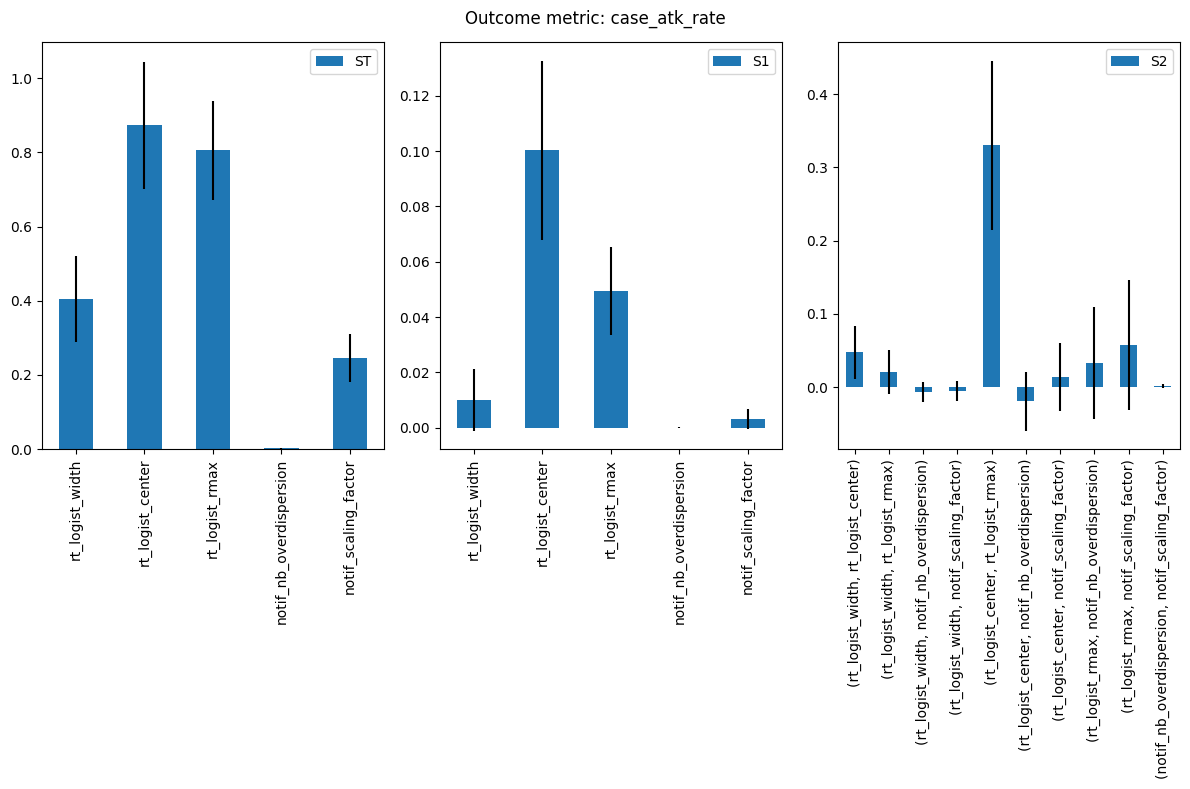

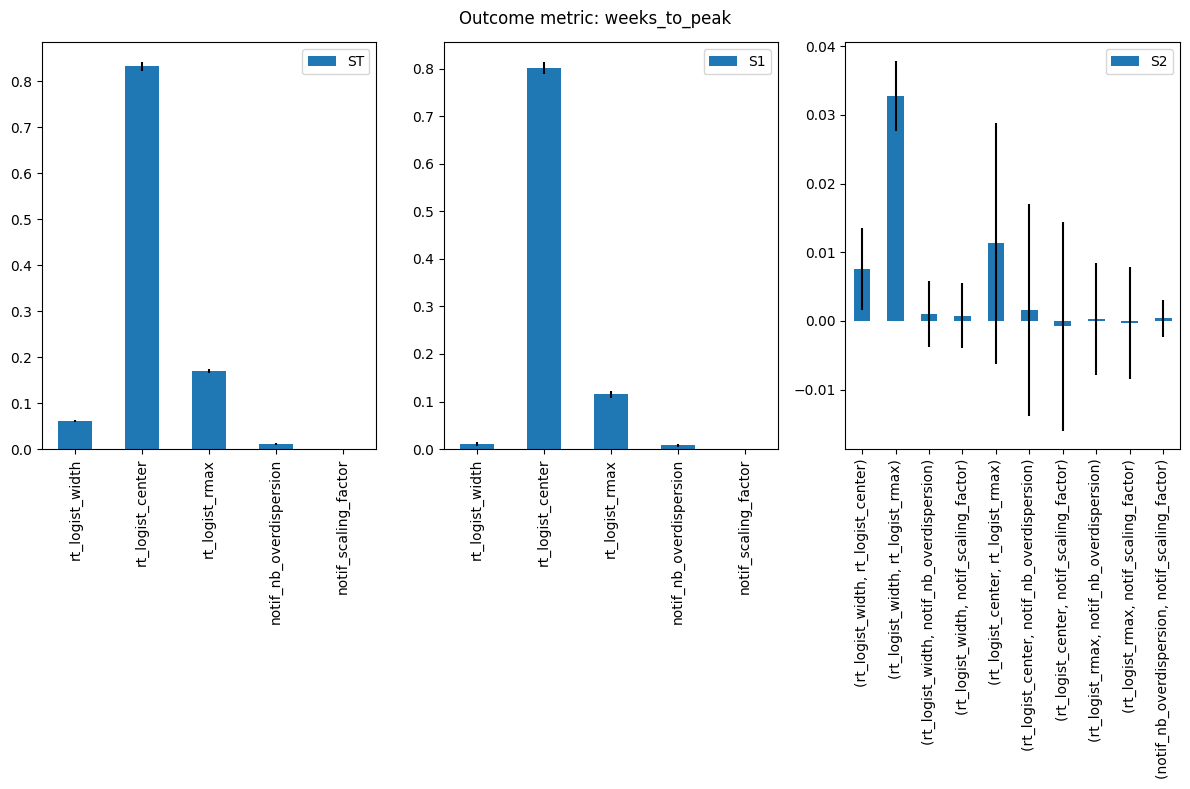

In [6]:
# --- Visualize results
for metric, sobol_result in sobol_results.items():
    print(f"Sensitivity of metric: {metric}\n===================")
    sobol_result: analyse_sobol.ResultDict
    fig, axes = plt.subplots(ncols=3, figsize=(12, 8))
    sobol_result.plot(ax=axes)

    fig.suptitle(f"Outcome metric: {metric}")
    fig.tight_layout()

    for _df in sobol_result.to_df():
        display(_df)



for _df in sobol_result.to_df():
    display(_df)

,ST,ST_conf
rt_logist_width,0.062813,0.008901
rt_logist_center,0.817690,0.056596
rt_logist_rmax,0.166882,0.019740
notif_nb_overdispersion,0.005938,0.006926
notif_scaling_factor,0.000000,0.000000


,S1,S1_conf
rt_logist_width,-0.005547,0.018449
rt_logist_center,0.789906,0.065280
rt_logist_rmax,0.099512,0.033398
notif_nb_overdispersion,0.005421,0.008923
notif_scaling_factor,0.000000,0.000000


,S2,S2_conf
"(rt_logist_width, rt_logist_center)",0.022609,0.032492
"(rt_logist_width, rt_logist_rmax)",0.048115,0.027625
"(rt_logist_width, notif_nb_overdispersion)",0.011563,0.026032
"(rt_logist_width, notif_scaling_factor)",0.011186,0.025950
"(rt_logist_center, rt_logist_rmax)",0.027671,0.078291
"(rt_logist_center, notif_nb_overdispersion)",0.001051,0.071290
"(rt_logist_center, notif_scaling_factor)",0.000716,0.071383
"(rt_logist_rmax, notif_nb_overdispersion)",0.016970,0.046064
"(rt_logist_rmax, notif_scaling_factor)",0.016970,0.046064
"(notif_nb_overdispersion, notif_scaling_factor)",-0.003012,0.013473
